# Post Model Testing Analysis (Part I)

In this notebook, we will examine why the best speaker age detection model *(model12-04.hdf5)* performed well on the Common Voice Dataset (91% accuracy) but performed poorly on the Speech Accent Archive Dataset (33% accuracy). There could be many reasons, but for now we will look at the following three reasons, and see if they hold true:

 1. Data Quality of Common Voice
 2. Significant Differences between Common Voice, and Speech Accent Archive

## (1) Data Quality of Common Voice

Let's load up our original test, train, and validation split of our Common Voice dataset.

In [1]:
import pandas as pd

testing_df = pd.read_csv("./datasets/common_voice/testing.csv")
training_df = pd.read_csv("./datasets/common_voice/training.csv")
validation_df = pd.read_csv("./datasets/common_voice/validation.csv")

The above dataframes have the following columns:
 * filename
 * up_votes
 * down_votes
 * locale
 * gender
 * age
 
If we assume that two different filenames coresspond to different audio files, then we would like to make sure there are no common filenames in any two distinct dataframes (i.e no data leakage).

In [2]:
list(
    set(testing_df.filename) & 
    set(training_df.filename) & 
    set(validation_df.filename)
)

[]

No evidence of leakage based on the filenames. There are some rows in the training dataframe where there are only down votes. This might imply a poor quality audio file. Let's check how many rows of that type occur in the training dataframe.

In [3]:
training_df[
    (training_df.up_votes < training_df.down_votes) &
    (training_df.up_votes == 0)
]

,filename,up_votes,down_votes,locale,gender,age
2,common_voice_en_22968508.mp3,0,2,en,male,30-39
6,common_voice_en_518620.mp3,0,2,en,female,under-20
14,common_voice_en_21109515.mp3,0,2,en,male,20-29
24,common_voice_en_22265442.mp3,0,2,en,female,20-29
40,common_voice_en_20392414.mp3,0,2,en,female,40-49
...,...,...,...,...,...,...
1066489,common_voice_en_19499522.mp3,0,2,en,male,30-39
1066490,common_voice_en_17686518.mp3,0,2,en,male,20-29
1066535,common_voice_en_19366985.mp3,0,2,en,male,20-29
1066536,common_voice_en_28071.mp3,0,2,en,female,50-59


There are many of them, let's remove it from our training dataframe.

In [4]:
training_df = training_df[
    (training_df.up_votes >= training_df.down_votes) |
    (training_df.up_votes != 0)
]
training_df.to_csv("./datasets/common_voice/training(1).csv", index=False)

And to keep things consistent, let's also remove down voted rows in both the validation set, and testing set.

In [5]:
validation_df = validation_df[
    (validation_df.up_votes >= validation_df.down_votes) |
    (validation_df.up_votes != 0)
]
validation_df.to_csv("./datasets/common_voice/validation(1).csv", index=False)

testing_df = testing_df[
    (testing_df.up_votes >= testing_df.down_votes) |
    (testing_df.up_votes != 0)
]
testing_df.to_csv("./datasets/common_voice/testing(1).csv", index=False)

The new files will be used to train a new model, and see if it makes improvements on the common voice dataset, or any other dataset.

## (2) Significant Differences between Common Voice, and Speech Accent Archive

*
Recall that the speech age detection model does the following steps to make a prediction on a speaker's age.
 1. It takes in an audio file, and converts it to a melspectrogram (as a numpy matrix),
 2. reshape the melspectrogram to a particular size so that you will the resulting numpy matrix, 
 3. rescale the numpy matrix so that every value in the matrix is between 0 and 1, and finally,
 4. feed the resulting matrix into the CNN model to get the predicted age group.

Because of the above process, there are number of factors from the input dataset that could affect the performance of our model. They are the following factors:

 * Audio Duration, and 
 * Melspectrograms Before Preprocessing, and Melspectrograms After Preprocessing.


***Note to Self: If the audio file is too large, the model will trim out the first part of an audio. Silent Segments might affect model performance.***

### Audio Duration

Here is the function that computes the length on an audio file *(Librosa's get duration)*.

In [6]:
import joblib
import pandas as pd
import seaborn as sns
import warnings

from librosa import load, get_duration

sns.set(rc={'figure.figsize': (15, 10)})

def compute_duration(mp3_filepath):
    warnings.filterwarnings("ignore", category=UserWarning)
    y, sr = load(mp3_filepath)
    
    return get_duration(y)

#### Speech Accent Archive

In [7]:
speech_accent_dataframe = pd.read_csv('./datasets/speech_accent_archive/metadata(1).csv')
speech_accent_filenames = list(speech_accent_dataframe.filename)
speech_accent_filepaths = [
    './datasets/speech_accent_archive/clips/%s' % filename
    for filename in speech_accent_filenames
]

speech_accent_jobs = [
    joblib.delayed(compute_duration)(filepath)
    for filepath in speech_accent_filepaths
]
speech_accent_durations = joblib.Parallel(n_jobs=12, verbose=1)(speech_accent_jobs)
speech_accent_dataframe['duration'] = speech_accent_durations

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    5.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   17.9s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   40.6s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 1084 out of 1084 | elapsed:  1.8min finished


In [8]:
speech_accent_dataframe.head(10)

,filename,gender,birthplace,country,age_english_onset,accent,age,duration
0,arabic10.mp3,male,"cairo, egypt",egypt,5.0,arabic,20-29,37.165442
1,arabic12.mp3,male,"baghdad, iraq",iraq,11.0,arabic,30-39,39.677052
2,arabic13.mp3,male,"zabbougha, lebanon",lebanon,15.0,arabic,20-29,30.231293
3,arabic2.mp3,male,"damascus, syria",syria,2.5,arabic,under-20,28.047710
4,arabic3.mp3,male,"doha, qatar",qatar,9.0,arabic,20-29,48.189297
5,arabic4.mp3,male,"sharjah, united arab emirates",united arab emirates,6.0,arabic,under-20,23.269615
6,arabic6.mp3,male,"sanaa, yemen",yemen,14.5,arabic,20-29,26.302857
7,arabic8.mp3,male,"casablanca, morocco",morocco,17.0,arabic,20-29,28.464399
8,arabic14.mp3,male,"amman, jordan",jordan,11.0,arabic,40-49,48.931202
9,arabic15.mp3,male,"qayrawan, tunisia",tunisia,33.0,arabic,40-49,37.364626


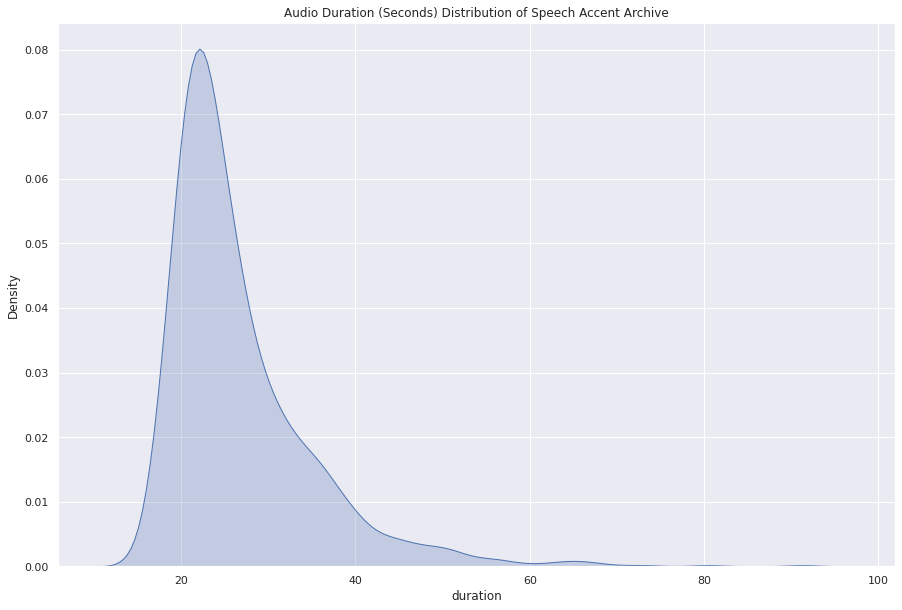

In [10]:
title = "Audio Duration (Seconds) Distribution of Speech Accent Archive"
params = {'x': 'duration', 'fill': True, 'data': speech_accent_dataframe}

plot = sns.kdeplot(**params).set(title=title)

By design, the speech accent archive dataset will have audio files that tend between 20 to 30 seconds. This is because each audio file from the Speech Accent Archive has one speaker reading the same paragraph. The speaker age detection model performed poorly on the speech accent archive dataset (33% accuracy).

#### Common Voice 

The common voice dataset was used to fully trained the model, particular we used the training set (80% train, 10% validation, and 10% testing). Once training is done, the model then gets evaluated on the validation set, and the testing set. Both datasets (validation, and testing) performed well with accuracy scores of 91%.

##### Training

This training set is very large (approximately 1 million samples), so getting the audio duration distribution of the entire set is computationally time consuming. Because of this, we will just sample 10,000 audio files from the training set, compute the sample mean and the sample standard deviation, and plot the sample audio duration.

In [11]:
training_dataframe = pd.read_csv('./datasets/common_voice/training.csv')
training_dataframe = training_dataframe.sample(n=10000, random_state=42)

training_filenames = list(training_dataframe.filename)
training_filepaths = [
    './datasets/common_voice/clips/%s' % filename
    for filename in training_filenames
]

training_jobs = [
    joblib.delayed(compute_duration)(filepath)
    for filepath in training_filepaths
]
training_durations = joblib.Parallel(n_jobs=12, verbose=1)(training_jobs)
training_dataframe['duration'] = training_durations

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.9s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.1s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   14.1s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   24.4s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   37.5s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:   54.3s
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.7min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  2.1min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  2.7min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.3min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  3.9min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  4.6min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  5.4min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

In [12]:
training_dataframe.head(10)

,filename,up_votes,down_votes,locale,gender,age,duration
922806,common_voice_en_19654880.mp3,2,1,en,male,under-20,4.848027
911000,common_voice_en_28896900.mp3,2,0,en,male,60+,5.544036
422872,common_voice_en_17693239.mp3,2,0,en,male,50-59,6.480000
845966,common_voice_en_19439589.mp3,2,0,en,other,under-20,5.064036
992893,common_voice_en_27572149.mp3,2,0,en,male,20-29,4.572018
215541,common_voice_en_27462041.mp3,2,0,en,female,20-29,3.636009
726573,common_voice_en_23621198.mp3,2,0,en,male,20-29,6.144036
976865,common_voice_en_19497757.mp3,2,0,en,male,60+,8.208027
146411,common_voice_en_18713980.mp3,0,2,en,female,40-49,3.768027
780976,common_voice_en_27272188.mp3,1,2,en,female,40-49,5.508027


In [14]:
sample_mean_duration = training_dataframe['duration'].mean()
sample_std_duration = training_dataframe['duration'].std()

print("Sample Mean Duration:", sample_mean_duration)
print("Sample Std Duration:", sample_std_duration)

Sample Mean Duration: 5.116931732426305
Sample Std Duration: 1.8559470583528122


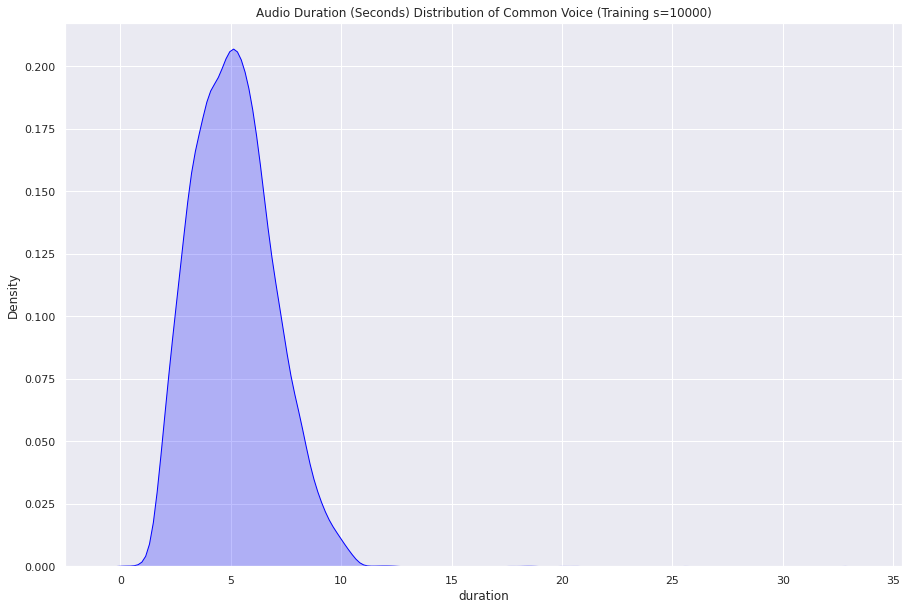

In [15]:
title = "Audio Duration (Seconds) Distribution of Common Voice (Training s=10000)"
params = {'x': 'duration', 'fill': True, 'color': 'blue', 'data': training_dataframe}

plot = sns.kdeplot(**params).set(title=title)

##### Validation

Same as the training section, but get the audio duration for the entire validation dataset.

In [16]:
validation_dataframe = pd.read_csv('./datasets/common_voice/validation.csv')
validation_filenames = list(validation_dataframe.filename)
validation_filepaths = [
    './datasets/common_voice/clips/%s' % filename
    for filename in validation_filenames
]

validation_jobs = [
    joblib.delayed(compute_duration)(filepath)
    for filepath in validation_filepaths
]
validation_durations = joblib.Parallel(n_jobs=12, verbose=1)(validation_jobs)
validation_dataframe['duration'] = validation_durations

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    6.3s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   12.9s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   22.4s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   34.7s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:   50.1s
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.6min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  2.1min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  2.6min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.1min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  3.7min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  4.4min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  5.1min
[Parallel(n_jobs=12)]: Done 11226 tasks      

In [17]:
validation_dataframe.head(10)

,filename,up_votes,down_votes,locale,gender,age,duration
0,common_voice_en_28547809.mp3,2,0,en,female,60+,7.848027
1,common_voice_en_21572996.mp3,0,2,en,male,30-39,7.416009
2,common_voice_en_18698002.mp3,2,0,en,male,30-39,5.352018
3,common_voice_en_18257460.mp3,0,0,en,male,20-29,2.904036
4,common_voice_en_27287889.mp3,2,0,en,female,20-29,6.408027
5,common_voice_en_30588718.mp3,2,0,en,male,30-39,4.104036
6,common_voice_en_23319122.mp3,2,0,en,male,40-49,4.296009
7,common_voice_en_508933.mp3,2,0,en,male,30-39,4.080000
8,common_voice_en_669915.mp3,2,0,en,male,20-29,1.200000
9,common_voice_en_28973098.mp3,2,1,en,male,20-29,6.696009


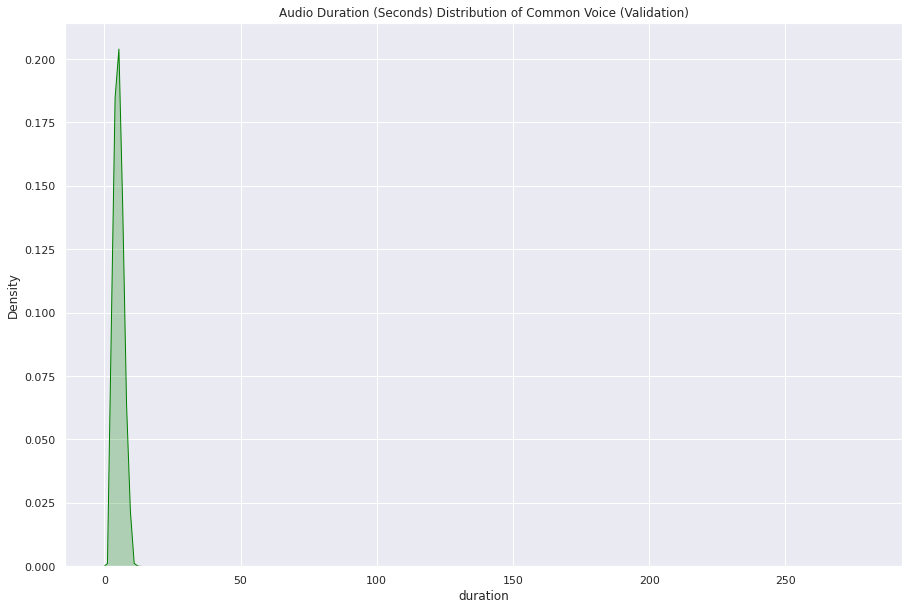

In [19]:
title = "Audio Duration (Seconds) Distribution of Common Voice (Validation)"
params = {'x': 'duration', 'fill': True, 'color': 'green', 'data': validation_dataframe}

plot = sns.kdeplot(**params).set(title=title)

##### Testing

Same as the training section, but get the audio duration for the entire testing dataset.

In [20]:
testing_dataframe = pd.read_csv('./datasets/common_voice/testing.csv')
testing_filenames = list(testing_dataframe.filename)
testing_filepaths = [
    './datasets/common_voice/clips/%s' % filename
    for filename in testing_filenames
]

testing_jobs = [
    joblib.delayed(compute_duration)(filepath)
    for filepath in testing_filepaths
]
testing_durations = joblib.Parallel(n_jobs=12, verbose=1)(testing_jobs)
testing_dataframe['duration'] = testing_durations

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.8s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.7s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   11.4s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   20.7s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   32.5s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:   47.4s
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.1min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.5min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  1.9min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  2.4min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.0min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  3.6min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  4.2min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  4.9min
[Parallel(n_jobs=12)]: Done 11226 tasks      

In [21]:
testing_dataframe.head(10)

,filename,up_votes,down_votes,locale,gender,age,duration
0,common_voice_en_29318471.mp3,0,2,en,male,20-29,5.616009
1,common_voice_en_22146442.mp3,2,0,en,male,20-29,1.704036
2,common_voice_en_29709822.mp3,2,0,en,male,20-29,6.948027
3,common_voice_en_598307.mp3,2,0,en,male,40-49,2.448027
4,common_voice_en_17936716.mp3,2,0,en,other,under-20,2.184036
5,common_voice_en_17279669.mp3,2,1,en,male,40-49,3.312018
6,common_voice_en_19846098.mp3,0,2,en,female,40-49,6.576009
7,common_voice_en_9755.mp3,9,4,en,female,20-29,6.480000
8,common_voice_en_27151057.mp3,2,0,en,female,20-29,6.948027
9,common_voice_en_545399.mp3,2,0,en,male,30-39,3.984036


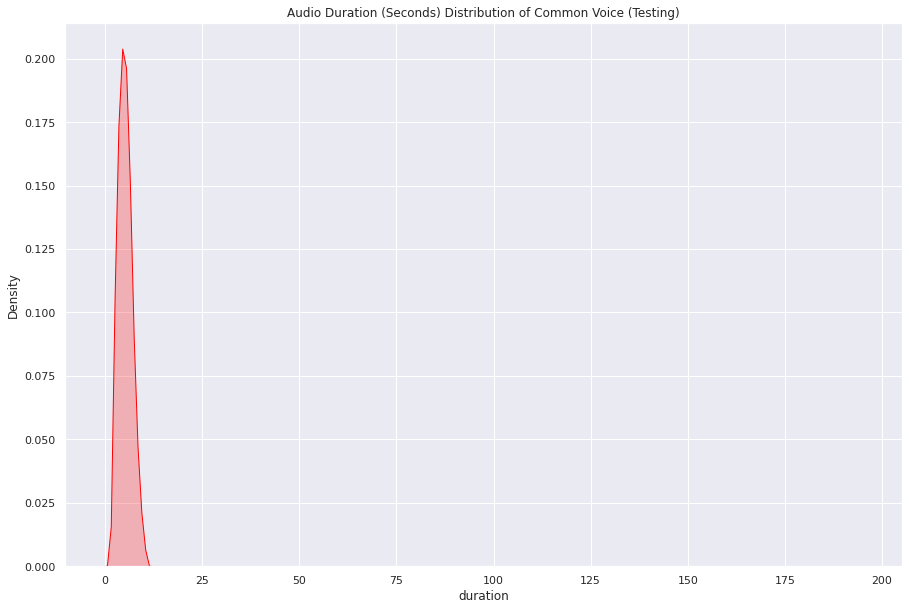

In [23]:
title = "Audio Duration (Seconds) Distribution of Common Voice (Testing)"
params = {'x': 'duration', 'fill': True, 'color': 'red', 'data': testing_dataframe}

plot = sns.kdeplot(**params).set(title=title)

### Melspectrograms

In [1]:
from helpers import display_melspectrogram, display_modified_melspectrogram

After running through the above helper functions several times, here is a summary of my findings:
 * Both the common voice dataset, and the speech accent archive dataset have segments where there is no sound. Because of this, it indicates that silent segemnts cannot contribute to the model's performance.
 * The duration of an audio file plays a more important role to the performance of our model. The speaker age detection model was trained on the Common Voice Dataset (Training) where the average duration is about 6 seconds. Once the audio file from the training set gets feed into the preprocessing phase, you will get an upsampled numpy matrix (i.e parts of the numpy matrix are repeated). That would be the reason why the model performed well on the validation set, and test set (Common Voice). The Speech Accent Archive Dataset, on the other hand, tend to be 20 to 30 seconds long. This means that if an audio file from the Speech Accent Archive gets feed into the preprocessing phase, the resulting matrix will only take the first few seconds of the origin melspectrogram.
 
(See Examples Below)

#### Speech Accent Melspectrograms Before Preprocessing

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


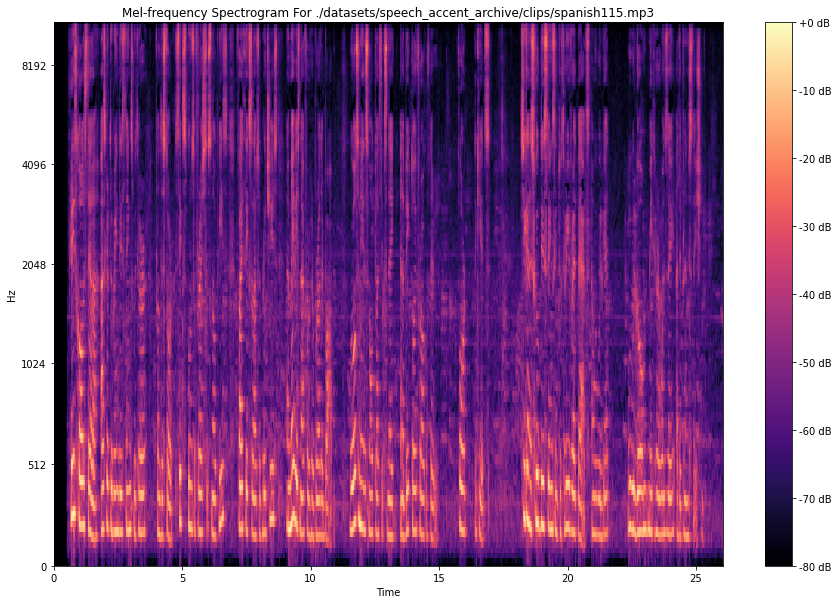

In [2]:
display_melspectrogram('./datasets/speech_accent_archive/clips/spanish115.mp3')

#### Speech Accent Melspectrograms After Preprocessing

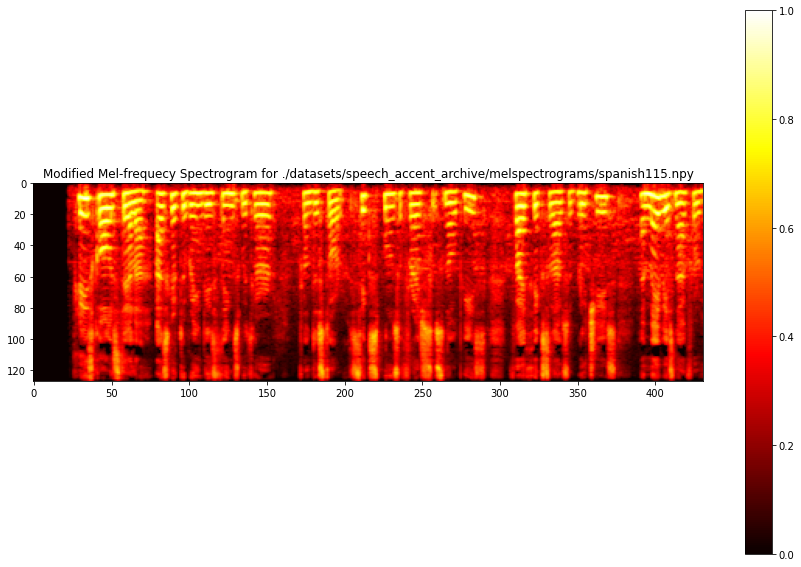

In [3]:
display_modified_melspectrogram('./datasets/speech_accent_archive/melspectrograms/spanish115.npy')

#### Common Voice Melspectrograms Before Preprocessing

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


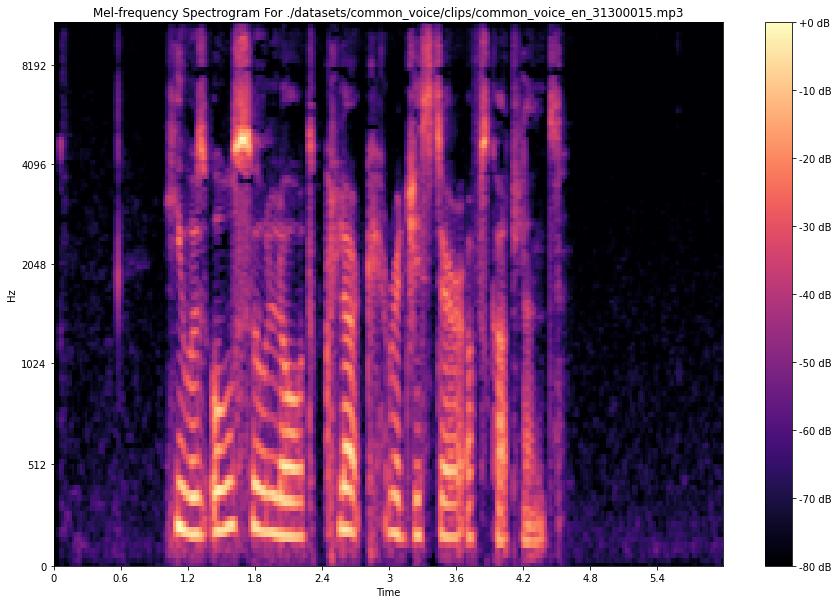

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


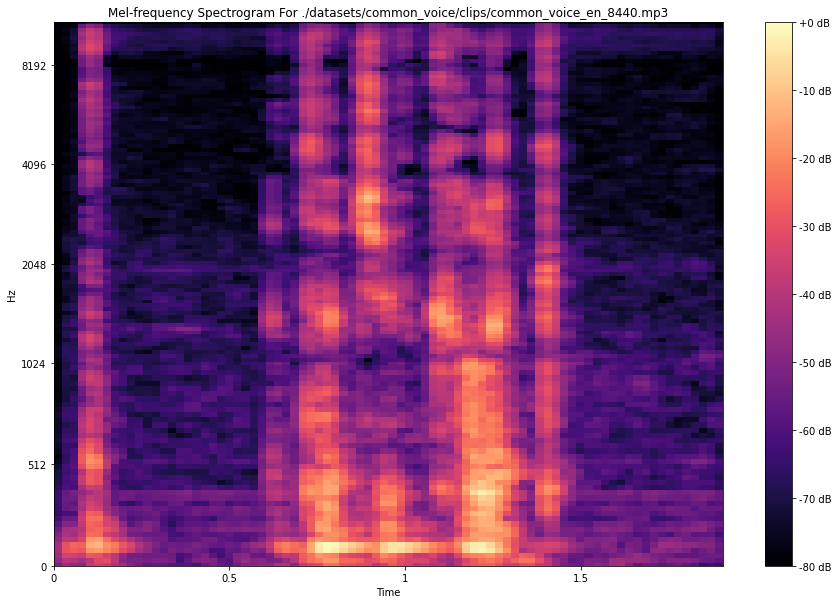

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


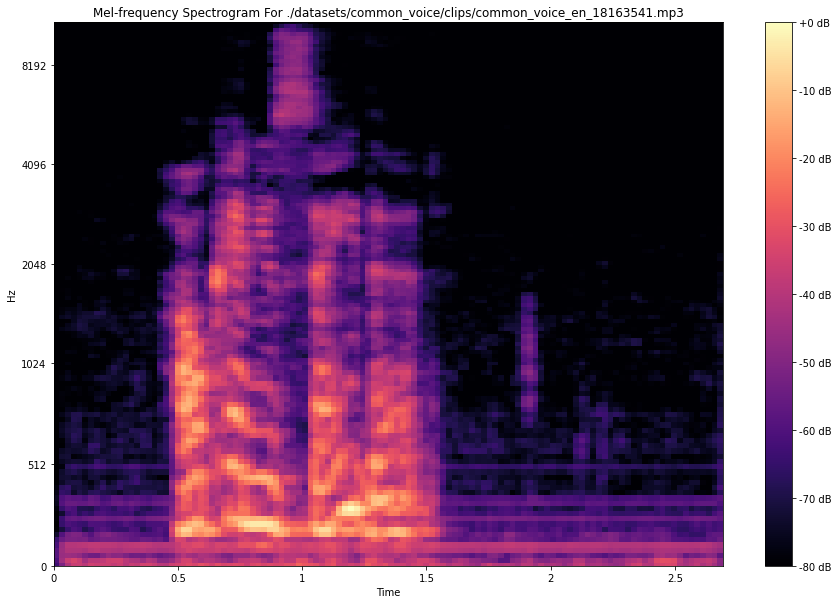

In [4]:
#From Training
display_melspectrogram('./datasets/common_voice/clips/common_voice_en_31300015.mp3')

#From Validation
display_melspectrogram('./datasets/common_voice/clips/common_voice_en_8440.mp3')

#From Testing
display_melspectrogram('./datasets/common_voice/clips/common_voice_en_18163541.mp3')

#### Common Voice Melspectrograms After Preprocessing

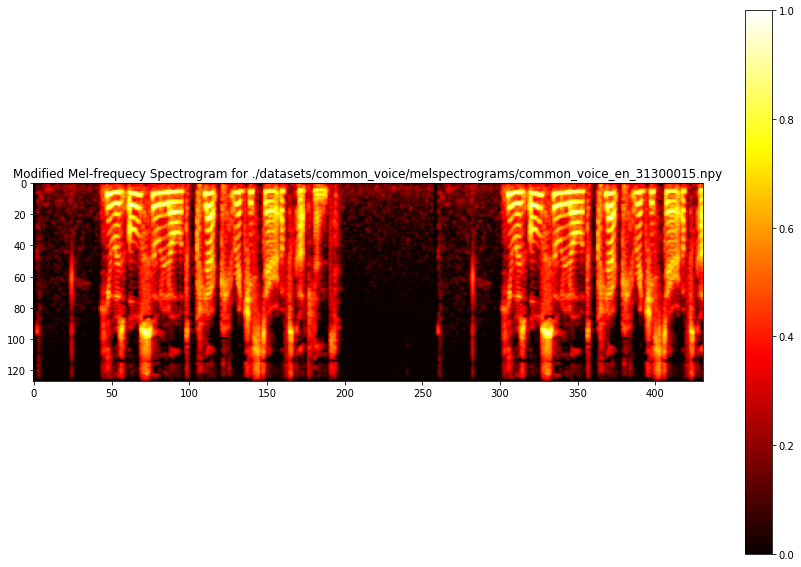

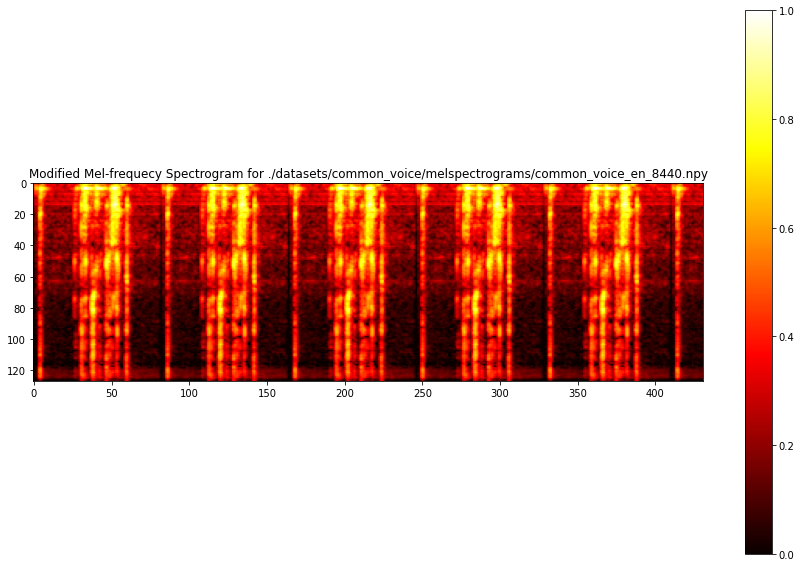

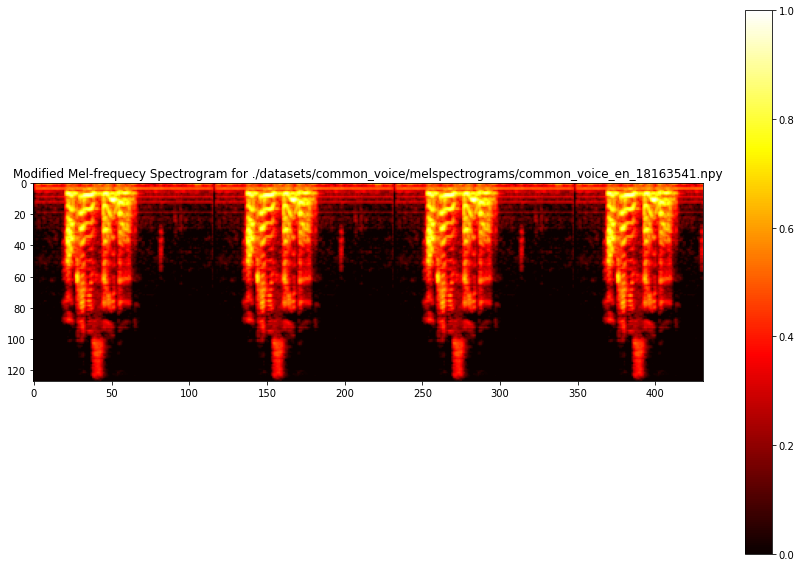

In [5]:
#From Training
display_modified_melspectrogram('./datasets/common_voice/melspectrograms/common_voice_en_31300015.npy')

#From Validation
display_modified_melspectrogram('./datasets/common_voice/melspectrograms/common_voice_en_8440.npy')

#From Testing
display_modified_melspectrogram('./datasets/common_voice/melspectrograms/common_voice_en_18163541.npy')